# Estimering af vaccineeffektivitet fra et randomiseret forsøg via tid-til-første-infektion


## Sammenfatning

## Estimering af vaccineeffektivitet fra et randomiseret forsøg

Et pivotalt fase III-vaccineforsøg randomiserer deltagere 1:1 til **vaccine** eller **placebo** og følger hver person indtil deres første laboratoriebekræftede infektion eller indtil administrativ censurering ved udgangen af inkluderings- og opfølgningsvinduet. Det regulatoriske primære endepunkt er **vaccineeffektivitet (VE)**, defineret som `VE = 1 - hazard ratio (vaccine vs. placebo)`. Fordi deltagerne indtræder på et forskudt skema, og de fleste aldrig bliver inficeret, er data højrecensurerede, og overlevelsesmetoder — ikke simple andele — giver det forsvarlige estimat.

Denne notebook gennemarbejder endepunktet fra ende til anden på et syntetisk balanceret forsøg med **100 forsøgspersoner (50 vaccine, 50 placebo)**:

- **PROC FREQ** opbygger angrebsratens to-gange-to (arm efter infektionsstatus) med chi-i-anden-testen, relativ risiko og risikoforskel — den beskrivende "rå VE"-visning, som en klinisk bedømmer ser først.
- **PROC MEANS** sammenfatter persontid (samlede og gennemsnitlige opfølgningsdage) og de rå infektionstal per arm og afdækker censureringsubalancen, der motiverer en tid-til-hændelse-model.
- **PROC LIFETEST** estimerer Kaplan-Meier-overlevelseskurverne per arm og kører **log-rank- og Wilcoxon**-homogenitetstestene — den ikke-parametriske bekræftelse af, at kurverne separerer.
- **PROC PHREG** tilpasser Cox proportional-hazard-modellen justeret for alder, køn og eksponeringsrisiko ved baseline, rapporterer hazard ratio med dens 95 %-konfidensgrænser, og **HAZARDRATIO**-sætningen indrammer arm-kontrasten direkte. Den justerede VE aflæses som `1 - HR`.

**Sådan læses resultatet.** I den verificerede kørsel er den rå infektionsandel **64 % i placebo mod 30 % i vaccine** (chi-i-anden p = 0.0007), log-rank-testen forkaster lighed mellem overlevelseskurverne (χ² = 11.25, p = 0.0008), og den justerede Cox hazard ratio for vaccine vs. placebo er **0.369** med et 95 %-konfidensinterval på **(0.198, 0.687)** — helt under 1 — dvs. en estimeret VE på omkring **63 %** (`1 - 0.369`). Den øvre HR-konfidensgrænse på 0.687 svarer til en nedre effektivitetsgrænse nær 31 %, på kanten af den konventionelle 30-50 %-tærskel for godkendelse for et studie af denne størrelse. Højeksponeringserhverv ved baseline tredobler groft sagt infektionshazardet (HR = 3.47, p < .0001), hvilket bekræfter, at kovariatjusteringen har betydning; alder og køn har grænseeffekter (p ≈ 0.06), der ikke når signifikans på 0.05-niveauet. Overensstemmelsen mellem den rå to-gange-to, de separerede KM-kurver og det justerede Cox-estimat er netop den triangulering, som et Data Safety Monitoring Board forventer, før effektivitet erklæres.

*Kun syntetiske data — genereret inline med `streaminit`/`rand`; ingen eksterne filer eller netværk. Kører på et godt stykke under et minut.*

## Datakilder

**Syntetisk datasæt `trial`** — én række per inkluderet deltager, genereret inline i den første kodecelle (frø `20260605`). 100 forsøgspersoner, balanceret 1:1 (50 vaccine, 50 placebo), eksponentiel tid-til-infektion med en ~70 % hazardreduktion i vaccinearmen, forskudt indtræden og administrativ censurering ved udgangen af et 540-dages vindue.

| Variabel | Type | Beskrivelse |
|----------|------|-------------|
| `subjid` | Num | Forsøgspersonens identifikator (1-100) |
| `arm` | Char | Behandlingsarm: `Vaccine` eller `Placebo` |
| `arm_n` | Num | Numerisk arm-flag (1 = vaccine, 0 = placebo) |
| `age` | Num | Alder i år ved inklusion (18-85) |
| `sex` | Char | Køn: `F` eller `M` |
| `baseline_risk` | Num | Indikator for højeksponeringserhverv (1 = ja) |
| `fu_days` | Num | Opfølgningstid i dage til første infektion eller censurering |
| `infected` | Num | Hændelsesindikator: 1 = infektion observeret, 0 = censureret |

# Estimering af vaccineeffektivitet fra et randomiseret forsøg

**Tid-til-første-infektion overlevelsesanalyse**

Det primære effektivitetsendepunkt i et vaccineforsøg er **infektionshazardet** i vaccinearmen relativt til placebo. Vi definerer

$$\text{VE} = 1 - \text{HR}_{\text{vaccine vs. placebo}}$$

Fordi deltagerne indtræder på et forskudt skema, og de fleste aldrig inficeres, før opfølgningen slutter, er data højrecensurerede: en simpel sammenligning af infektionsandele spilder tidsinformationen og er skæv på grund af ulige opfølgning. Vi opbygger derfor estimatet i tre lag — en rå angrebsrate-to-gange-to, ikke-parametriske Kaplan-Meier-kurver med en log-rank-test, og en justeret Cox proportional-hazard-model — og kontrollerer, at alle tre fortæller den samme historie.

Analysen anvender **PROC FREQ**, **PROC MEANS**, **PROC LIFETEST** og **PROC PHREG**.

## 1. Generér det syntetiske forsøg

Vi simulerer et balanceret 100-forsøgspersoners, 1:1 randomiseret forsøg (50 vaccine, 50 placebo — tildelt efter forsøgspersonens paritet, så armene er nøjagtigt lige store). Tid til første infektion trækkes fra en eksponentiel fordeling, hvis daglige hazard afhænger af arm (vaccinen skærer hazardet ned til 30 % af placebo), alder og et højeksponeringserhvervs-flag. Forskudt indtræden plus et fast 540-dages vindue giver realistisk højrecensurering: enhver, der ikke er inficeret ved udgangen af deres opfølgning, censureres.

In [1]:
/* Syntetisk randomiseret vaccineforsøg: tid til første infektion */
data trial;
    CALL streaminit(20260605);
    enroll_days = 540;            /* inklusion + opfølgningsvindue */
    GØR subjid = 1 TIL 100;
        /* 1:1 randomisering til vaccine vs placebo: 50 pr. arm,
           tildelt ved skiftende paritet for et præcist balanceret forsøg */
        HVIS mod(subjid, 2) = 1 SÅ GØR;
            arm = 'Vaccine'; arm_n = 1;
        SLUT;
        ELLERS GØR;
            arm = 'Placebo'; arm_n = 0;
        SLUT;

        /* baseline-kovariater */
        AGE = round(rand('NORMAL', 47, 14));
        HVIS AGE < 18 SÅ AGE = 18;
        HVIS AGE > 85 SÅ AGE = 85;
        HVIS rand('BERNOULLI', 0.52) = 1 SÅ sex = 'K'; ELLERS sex = 'M';
        baseline_risk = rand('BERNOULLI', 0.30);   /* højeksponeringserhverv */

        /* daglig infektionshazard: placebo-baseline, vaccine reducerer ~70% */
        base_rate = 0.0016;
        rr_age  = EXP(0.012 * (AGE - 47));
        rr_risk = 1 + 0.9 * baseline_risk;
        HVIS arm_n = 1 SÅ ve_factor = 0.30; ELLERS ve_factor = 1.0;
        daily_hazard = base_rate * rr_age * rr_risk * ve_factor;

        /* tid til første infektion fra eksponentiel hazard */
        u = rand('UNIFORM');
        t_inf = -LOG(u) / daily_hazard;

        /* administrativ censurering ved forskudt indgang */
        entry  = rand('INTEGER', 0, 120);
        t_cens = enroll_days - entry;

        HVIS t_inf <= t_cens SÅ GØR;
            fu_days = round(t_inf);
            infected = 1;
        SLUT;
        ELLERS GØR;
            fu_days = round(t_cens);
            infected = 0;
        SLUT;
        HVIS fu_days < 1 SÅ fu_days = 1;
        UDDATA;
    SLUT;
    MÆRKAT subjid="Forsøgsperson-id"
           arm="Behandlingsarm"
           AGE="Alder"
           sex="Køn"
           baseline_risk="Højeksponeringsrisiko"
           fu_days="Opfølgningsdage"
           infected="Inficeret";
    BEHOLD subjid arm arm_n AGE sex baseline_risk fu_days infected;
KØR;


NOTE: DATA trial


NOTE: Wrote trial (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. Angrebsrate to-gange-to

Den enkleste effektivitetsvisning: krydstabulér arm mod infektionsstatus. Chi-i-anden-testen spørger, om infektion er uafhængig af arm; `RELRISK` rapporterer den relative risiko og odds ratio; `RISKDIFF` giver den absolutte risikoforskel med dens konfidensinterval. Dette er det *rå* (ujusterede, opfølgnings-ignorerende) billede — nyttigt som en fornuftskontrol, men ikke det regulatoriske estimat.

                                                   The FREQ Procedure

Table of Behandlingsarm by Inficeret

Behandlingsarm |         0 |         1 |      Total
---------------+-----------+-----------+-----------
Placebo        |        18 |        32 |         50
---------------+-----------+-----------+-----------
Vaccine        |        35 |        15 |         50
---------------+-----------+-----------+-----------
Total          |        53 |        47 |        100

Statistics for Table of Behandlingsarm by Inficeret

Statistic                                DF  Value         Prob
--------------------------------------------------------------
Chi-Square                                1 11.6018       0.0007
Likelihood Ratio Chi-Square               1 11.8410       0.0006
Fisher's Exact Test                                      0.0012

Phi Coefficient                      0.3406
Contingency Coefficient              0.3224
Cramer's V                           0.3406


Column 1 Risk Est


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_arm_infected.spec.json
NOTE: PROC FREQ statement used.


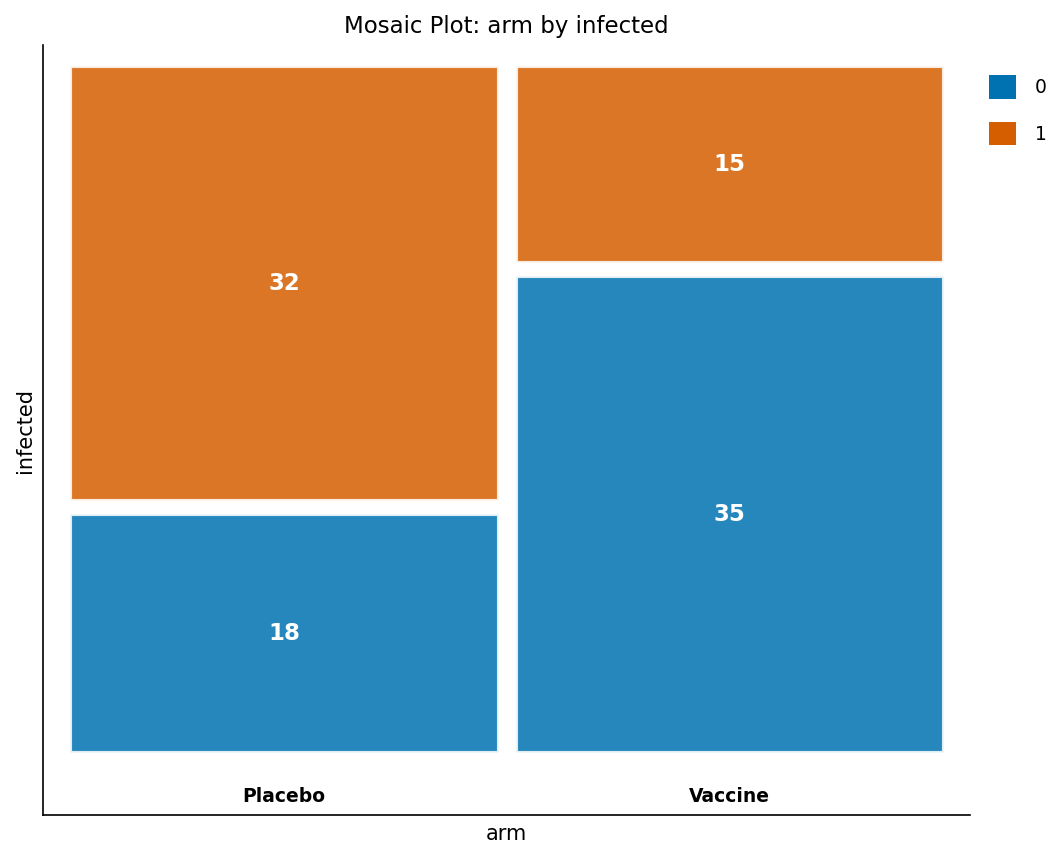

In [2]:
PROCEDURE FREKVENSER data=trial;
    TABLES arm*infected / chisq relrisk riskdiff nocol nopercent;
    MÆRKAT arm="Behandlingsarm" infected="Inficeret";
KØR;

## 3. Persontid og hændelsestal per arm

Før vi stoler på den rå to-gange-to, kvantificerer vi opfølgningsubalancen. `PROC MEANS` rapporterer samlede og gennemsnitlige opfølgningsdage plus infektionstallet i hver arm. Hvis vaccinearmen akkumulerer *mere* persontid (færre tidlige hændelser), undervurderer den rå andel effektiviteten — hvilket netop er grunden til, at vi går videre til en tid-til-hændelse-model.

In [3]:
PROCEDURE GENNEMSNIT data=trial n sum mean maxdec=2;
    KLASSE arm;
    VARIABEL fu_days infected;
    MÆRKAT arm="Behandlingsarm" fu_days="Opfølgningsdage" infected="Inficeret";
KØR;

                                                  The MEANS Procedure

                                      Analysis Variable : fu_days Opfølgningsdage

        Behandlingsarm          N Obs            Sum           Mean
        -----------------------------------------------------------
        Placebo                    50       14552.00         291.04
        Vaccine                    50       19438.00         388.76
        -----------------------------------------------------------

                                         Analysis Variable : infected Inficeret

        Behandlingsarm          N Obs            Sum           Mean
        -----------------------------------------------------------
        Placebo                    50          32.00           0.64
        Vaccine                    50          15.00           0.30
        -----------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Kaplan-Meier-kurver og log-rank-test

`PROC LIFETEST` estimerer produkt-limit-overlevelsesfunktionen (Kaplan-Meier) — her sandsynligheden for at forblive infektionsfri over tid — separat for hver arm. `STRATA arm / test=(logrank wilcoxon)` anmoder om de to standardhomogenitetstest: **log-rank**-testen vægter alle hændelsestidspunkter ens (mest kraftfuld under proportionale hazards), mens **Wilcoxon** opvægter tidlige hændelser. Overensstemmelse mellem dem understøtter den proportional-hazard-antagelse, som Cox-modellen vil bygge på. `ATRISK` annoterer antallet, der stadig er i risiko.

                                     Kaplan-Meier-overlevelse efter behandlingsarm                                      

    The LIFETEST Procedure    

                             N
--------------------  --------
Total                      100
Event                       47
Censored                    53
Median Survival Time  427.5000

Stratum: Behandlingsarm = Placebo

                             N
--------------------  --------
Total                       50
Event                       32
Censored                    18
Median Survival Time  324.0000

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
  9.0000    0.9800     0.0198              50                 1
 17.0000    0.9600     0.0277              49                 1
 23.0000    0.9400     0.0336              48                 1
 26.0000    0.9200     0.0384              47       


NOTE: Option TITLE changed to Kaplan-Meier-overlevelse efter behandlingsarm.
NOTE: PROC LIFETEST data=trial

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


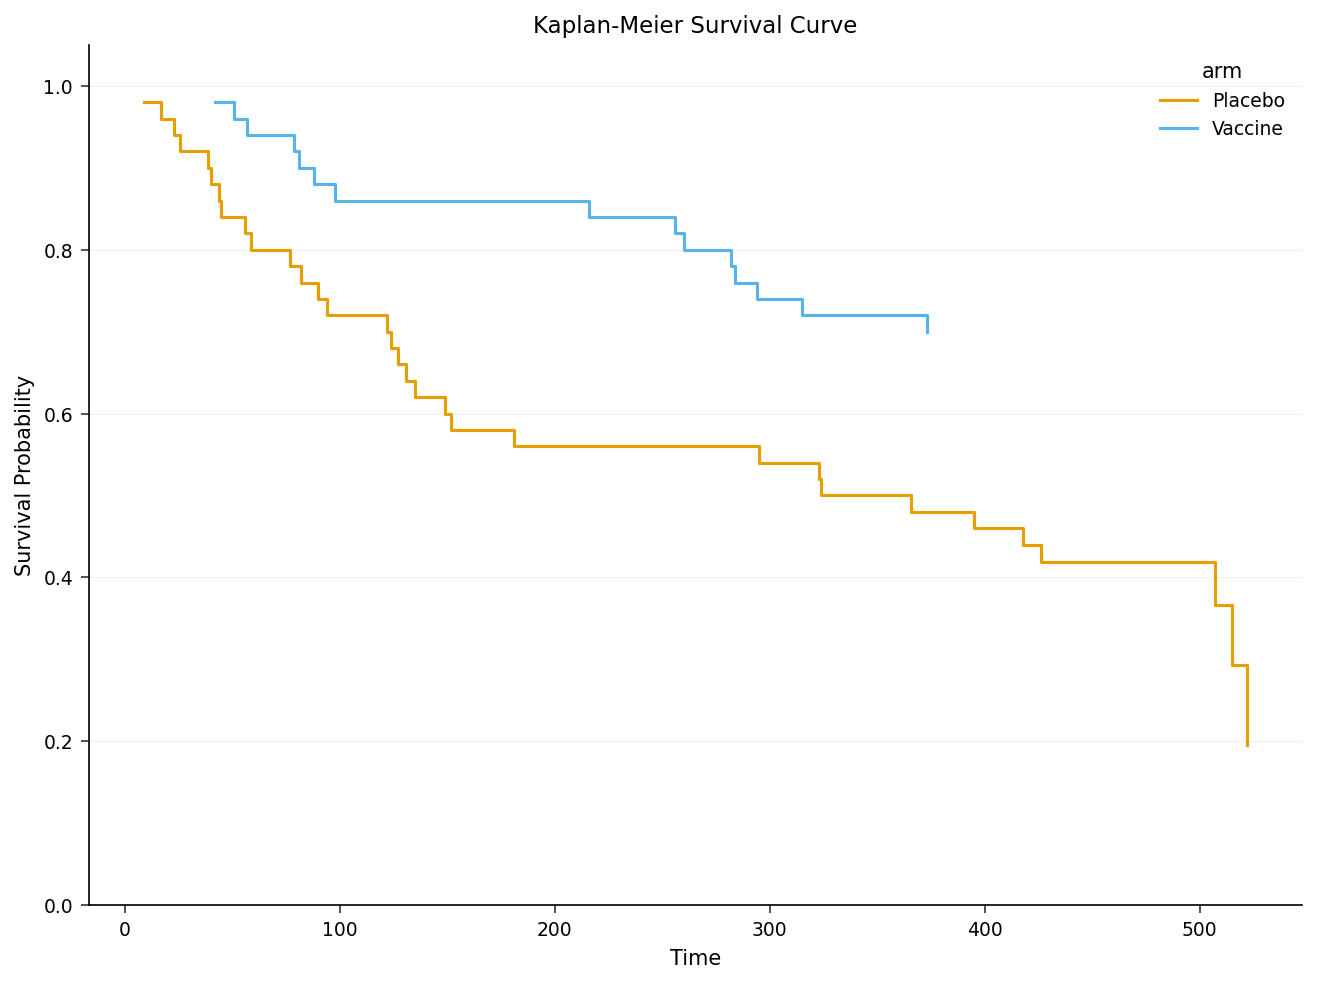

In [4]:
TITEL "Kaplan-Meier-overlevelse efter behandlingsarm";
PROCEDURE LIFETEST data=trial PLOTS=SURVIVAL atrisk;
    TIME fu_days*infected(0);
    STRATA arm / TEST=(logrank WILCOXON);
    MÆRKAT arm="Behandlingsarm" fu_days="Opfølgningsdage";
KØR;
TITEL;

## 5. Justeret Cox-model og vaccineeffektivitet

Cox proportional-hazard-modellen giver den **justerede** hazard ratio, kontrolleret for alder, køn og eksponeringsrisiko ved baseline. `CLASS arm(ref='Placebo') sex(ref='M') / param=ref` sætter referencekodning, så `ARM`-koefficienten er log-hazard-ratioen af vaccine vs. placebo. `TIES=EFRON` er den anbefalede metode til håndtering af sammenfald; `RL` udskriver hazard-ratioens konfidensgrænser. `HAZARDRATIO`-sætningerne rapporterer arm-kontrasten (Wald CL) og aldersvirkningen per 10-års stigning.

**Vaccineeffektiviteten aflæses direkte som `VE = 1 - HR` for arm-termen**, og den øvre konfidensgrænse for HR svarer til den nedre effektivitetsgrænse, som godkendelsesbeslutninger afhænger af.

In [5]:
PROCEDURE PHREG data=trial;
    KLASSE arm(REF='Placebo') sex(REF='M') / PARAM=REF;
    MODEL fu_days*infected(0) = arm AGE sex baseline_risk / TIES=efron rl;
    MÆRKAT arm="Behandlingsarm" AGE="Alder" sex="Køn"
           baseline_risk="Højeksponeringsrisiko"
           fu_days="Opfølgningsdage";
    hazardratio 'Vaccine vs Placebo' arm / cl=wald;
    hazardratio AGE / units=10;
KØR;

        The PHREG Procedure        

Criterion                     Value
----------------------  -----------
Number of Observations          100
Number of Events                 47
-2 LOG L                    368.882
Ties Handling                 efron
Convergence Status      0 Converged

      Testing Global Null Hypothesis: BETA=0      

Test              Chi-Square        DF  Pr > ChiSq
----------------  ----------  --------  ----------
Likelihood Ratio     29.0183         4      <.0001
Wald                 28.4562         4      <.0001
Score (Log-Rank)     30.6491         4      <.0001

                                          Analysis of Maximum Likelihood Estimates                                          

Parameter                     DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio  95% Lower CL  95% Upper CL
----------------------  --------  --------  --------------  ----------  ----------  ------------  ------------  ------------
ARM_VACCINE               


NOTE: PROC PHREG data=trial

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using Python wrapper


## Fortolkning

De tre lag triangulerer til en enkelt effektivitetskonklusion:

- **Rå angrebsrate (PROC FREQ).** Infektionsandelen er **64 % i placebo (32/50) mod 30 % i vaccine (15/50)** — en risikoforskel på **-0.34** (95 % CI -0.524 til -0.156) og en odds ratio på **0.241** (95 % CI 0.105 til 0.556). Chi-i-anden-testen forkaster uafhængighed (χ² = 11.60, p = 0.0007). Dette er det umiddelbare signal, en bedømmer forventer først — men det ignorerer den forskudte, ulige opfølgning.

- **Persontid (PROC MEANS).** Den gennemsnitlige opfølgning er længere i vaccinearmen (**388.8 mod 291.0 dage**) netop fordi færre deltagere udgår tidligt via infektion (15 vaccinehændelser mod 32 placebo). Det bekræfter, at den rå andel er en konservativ, opfølgnings-konfunderet visning og retfærdiggør tid-til-hændelse-analysen.

- **Kaplan-Meier + log-rank (PROC LIFETEST).** Overlevelseskurverne separerer tydeligt — placebo når en **median infektionsfri tid på 324 dage, mens vaccinemedianen ikke nås** (kun 15 af 50 vaccinerede blev nogensinde inficeret). Begge homogenitetstest forkaster lighed: **log-rank χ² = 11.25 (p = 0.0008)** og **Wilcoxon χ² = 9.11 (p = 0.0025)**. Deres overensstemmelse understøtter den proportional-hazard-antagelse, der ligger til grund for Cox-modellen.

- **Justeret Cox-model (PROC PHREG).** Efter justering for alder, køn og eksponeringsrisiko ved baseline er hazard ratioen vaccine-mod-placebo **0.369** med et 95 %-konfidensinterval på **(0.198, 0.687)** helt under 1 (p = 0.0017), hvilket giver en estimeret **vaccineeffektivitet på omkring 63 %** (`VE = 1 - 0.369`). Den nedre effektivitetsgrænse (fra den øvre HR-konfidensgrænse på 0.687) er nær **31 %**, på kanten af den konventionelle 30-50 %-tærskel for godkendelse — bred, som forventet for et 100-forsøgspersoners studie. Højeksponeringserhverv tredobler groft sagt infektionshazardet (**HR = 3.47**, 95 % CI 1.90-6.35, p < .0001), hvilket bekræfter, at kovariatjustering er berettiget; alder (HR = 1.022 per år, p = 0.059) og kvindeligt køn (HR = 0.541, p = 0.064) har grænseeffekter, der ikke når signifikans på 0.05-niveauet. Den globale nulhypotese forkastes (likelihood-ratio χ² = 29.0, p < .0001).

**Konklusion.** Fordi den rå to-gange-to, de separerede Kaplan-Meier-kurver og det justerede Cox-estimat alle peger i samme retning med konfidensintervaller, der udelukker ingen effekt, understøtter forsøget et effektivitetssignal — selvom de brede konfidensgrænser afspejler den lille stikprøve. I en reel indsendelse ville Cox `1 - HR`-estimatet og dets konfidensinterval — ikke den rå andel — være det primære endepunkt, med FREQ- og LIFETEST-outputtene som den understøttende beskrivende og ikke-parametriske bekræftelse, som et Data Safety Monitoring Board gennemgår sammen med det.